#  분류 ② 결정트리

**핵심 질문**: 모델이 "왜 그렇게 판단했는지" 사람이 읽을 수 있을까?

**오늘의 목표**
1. **스무고개 비유**: 결정 트리 = if-else 규칙으로 분류하는 모델
2. **불순도(Gini/Entropy)**: 트리가 "어떤 질문을 먼저 할지" 결정하는 기준
3. **Graphviz로 트리 시각화**: 노드를 읽는 법
4. **과적합**: max_depth=None → train 1.0, test↓ — 왜 위험한가
5. **가지치기**: max_depth, min_samples_split, min_samples_leaf
6. **Feature Importance**: 어떤 변수가 중요했나
7. **GridSearchCV**: 최적 하이퍼파라미터 조합 탐색

**예제**: Iris (Graphviz 트리 시각화), make_classification 2D (과적합 vs 일반화 경계 비교)

---
## 복습 → 결정 트리로의 전환

두 가지 분류 방식을 배움:

| 알고리즘 | 핵심 아이디어 | 경계 모양 | 4회차 |
|---------|-------------|----------|:-----:|
| **로지스틱 회귀** | 점수 → 확률 → 분류 | 직선 (선형) | 4-1 |
| **KNN** | 가까운 이웃끼리 다수결 | 복잡한 곡선 | 4-2 |
| **결정 트리** | 질문을 반복해서 분류 | 축에 평행한 계단 | **오늘!** |

> 로지스틱 회귀: "확률이 0.5 넘으면 양성"  
> KNN: "가까운 이웃이 양성이면 나도 양성"  
> **결정 트리: "질문에 예/아니오로 답하면서 분류"**

### 결정 트리의 가장 큰 장점

- 로지스틱 회귀: 계수(가중치)를 봐야 해석 가능
- KNN: 해석이 거의 불가능 ("이웃이 이렇게 생겼으니까")
- **결정 트리: 사람이 직접 규칙을 읽을 수 있음!**

> **"왜 이렇게 예측했는지"를 사람에게 설명할 수 있는 모델**

---
## Part 1. 스무고개 비유 — if-else 규칙으로 분류

### 결정 트리란?

결정 트리는 사람이 **스무고개** 하듯이, 질문을 하나씩 던져가며 분류하는 모델

```
Q1. 꽃잎 길이가 2.5cm보다 짧나요?
    ├── 예 → setosa!
    └── 아니오
        Q2. 꽃잎 너비가 1.75cm보다 좁나요?
            ├── 예 → versicolor!
            └── 아니오 → virginica!
```

### 트리 구조의 용어

| 용어 | 의미 | 비유 |
|------|------|------|
| **루트 노드 (Root)** | 가장 첫 번째 질문 | 스무고개 첫 질문 |
| **내부 노드 (Internal)** | 중간 질문들 | 이어지는 질문들 |
| **잎 노드 (Leaf)** | 최종 답 (예측 라벨) | "정답은 OO!" |
| **깊이 (Depth)** | 루트에서 잎까지 질문 횟수 | 몇 번 질문했나 |
| **분기 (Split)** | 질문에 따라 데이터를 나누는 것 | 예/아니오로 갈라짐 |

### 결정 트리의 핵심 질문

> **"어떤 질문을 먼저 해야 가장 효율적으로 분류할 수 있을까?"**

- 스무고개에서도 "동물인가요?" 같은 **큰 질문을 먼저** 하면 효율적
- 결정 트리도 마찬가지 — **불순도를 가장 많이 줄이는 질문부터** 함
- 불순도(Impurity)란? → Part 2에서 자세히!

---
## Part 2. Iris 데이터로 결정 트리 시작하기

먼저 코드로 결정 트리가 어떻게 동작하는지 확인하고,  
그 다음 "왜 이런 규칙이 만들어졌는지" (불순도)를 이해해 봅세

In [3]:
import numpy as np, pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import plotly.figure_factory as ff
import plotly.express as px
import plotly.graph_objects as go
import graphviz

iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
target_names  = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 결정 트리(max_depth=None == 깊이 제한 없음)
dt = DecisionTreeClassifier(max_depth=None, random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=target_names, digits=3))

Accuracy: 0.9333333333333333

              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      0.900     0.900     0.900        10
   virginica      0.900     0.900     0.900        10

    accuracy                          0.933        30
   macro avg      0.933     0.933     0.933        30
weighted avg      0.933     0.933     0.933        30



In [4]:
cm = confusion_matrix(y_test, y_pred)
fig = ff.create_annotated_heatmap(
    z=cm, x=list(target_names), y=list(target_names),
    colorscale="Blues", showscale=True
)
fig.update_layout(title="Confusion Matrix (Decision Tree, max_depth=None)",
                  xaxis=dict(title="Predicted"), yaxis=dict(title="Actual"),
                  template="plotly_dark")
fig.show()

> 결정 트리는 **스케일링 없이도** 잘 작동함!  
> KNN과 달리 거리를 계산하지 않기 때문에 피처의 범위가 달라도 상관없음.  
> 그런데 이 모델은 **어떤 규칙으로** 분류한 걸까?  
> → Graphviz로 트리를 시각화해서 직접 읽어보자!

---
## Part 3. Graphviz로 트리 시각화 — 노드 읽는 법

결정 트리의 가장 큰 장점: **규칙을 사람이 직접 읽을 수 있음!**

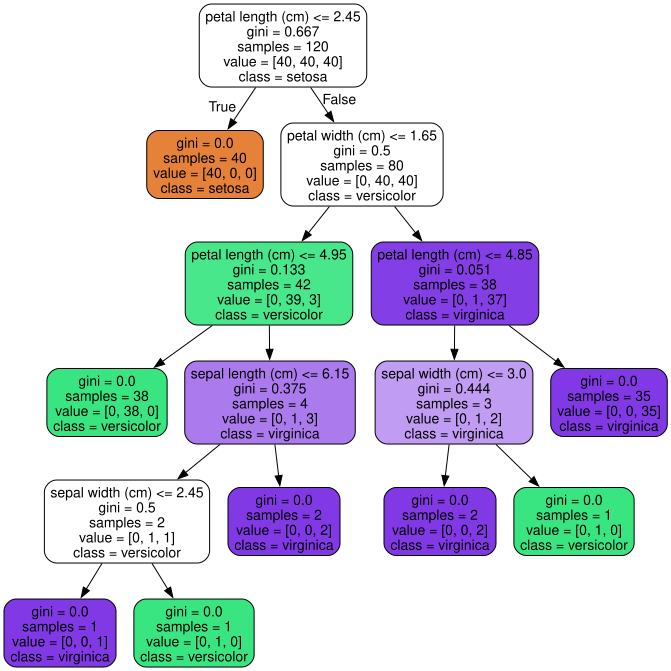

In [5]:
# Graphviz로 트리 시각화 (깊이 제한 없는 트리)
dot = export_graphviz(
    dt,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True,
    impurity=True   # 이 아이 중요함
)
graphviz.Source(dot)

### 노드 읽는 법 (5가지 정보)

트리의 각 노드(상자)에는 5가지 정보가 있음:

| 항목 | 의미 | 예시 |
|------|------|------|
| **`feature ≤ value`** | 분기 조건 (질문) | `petal length ≤ 2.45` → "꽃잎 길이가 2.45 이하인가?" |
| **`gini`** | 불순도 (0이면 한 클래스만, 0.5면 반반) | `gini = 0.0` → 완벽히 분류됨 |
| **`samples`** | 해당 노드에 도달한 샘플 수 | `samples = 40` |
| **`value`** | 클래스별 샘플 수 | `value = [0, 38, 2]` → setosa 0개, versicolor 38개, virginica 2개 |
| **`class`** | 이 노드의 예측 클래스 (value에서 가장 많은 것) | `class = versicolor` |

### 읽는 순서

```
1. 루트 노드의 질문을 읽는다 (feature ≤ value)
2. 조건이 참(예) → 왼쪽 자식 노드로
3. 조건이 거짓(아니오) → 오른쪽 자식 노드로
4. 잎 노드에 도달하면 class를 읽는다 → 이것이 최종 예측!
```

### 색상의 의미

- **색이 진할수록** → 불순도가 낮음 (한 클래스가 지배적)
- **색이 연할수록** → 불순도가 높음 (여러 클래스가 섞여 있음)
- 노드 색상 자체는 해당 노드에서 **가장 많은 클래스**를 나타냄

### 깊이를 제한한 트리 시각화 (max_depth=3)

위 트리는 후..... 깊이를 제한해봅세!

Train Accuracy: 0.983
Test  Accuracy: 0.967


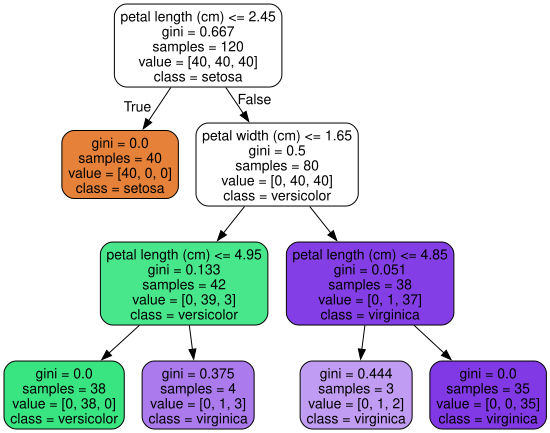

In [6]:
dt_depth3 = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_depth3.fit(X_train, y_train)

print(f"Train Accuracy: {accuracy_score(y_train, dt_depth3.predict(X_train)):.3f}")
print(f"Test  Accuracy: {accuracy_score(y_test, dt_depth3.predict(X_test)):.3f}")

dot3 = export_graphviz(
    dt_depth3, out_file=None,
    feature_names=feature_names, class_names=target_names,
    filled=True, rounded=True, impurity=True
)
graphviz.Source(dot3)

> **max_depth=3**이면 최대 3번 질문만 할 수 있음  
> 트리가 단순해지면서 **읽기 쉬워지고**, 과적합도 줄어듦  
> 하지만 너무 단순하면 성능이 떨어질 수 있음 → 적절한 균형이 필요!

---
## Part 4. 불순도(Impurity) — 트리가 "어떤 질문을 할지" 결정하는 기준

### 핵심 질문: 트리는 왜 첫 번째 질문으로 petal length를 선택했을까?

결정 트리는 **불순도(Impurity)를 가장 많이 줄이는 질문부터** 선택함

### 불순도란?

한 노드에 **여러 클래스가 섞여 있을수록** 불순도가 높음

| 상태 | 불순도 | 비유 |
|------|:-----:|------|
| [setosa 40개, versicolor 0개, virginica 0개] | **0** (깨끗) | 한 과일만 담긴 바구니 |
| [setosa 20개, versicolor 20개, virginica 0개] | **높음** (섞임) | 두 과일이 섞인 바구니 |
| [setosa 14개, versicolor 13개, virginica 13개] | **최대** (골고루) | 모든 과일이 섞인 바구니 |

> **좋은 질문 = 불순도를 크게 줄이는 질문**  
> 예: "꽃잎 길이 ≤ 2.45?"로 나누면 왼쪽은 setosa만 → 불순도 0!

### Gini Impurity (지니 불순도)

sklearn 기본값. 계산이 빠르고 직관적

$$\text{Gini} = 1 - \sum_{i=1}^{C} p_i^2$$

- $p_i$: 해당 노드에서 클래스 i의 비율
- $C$: 클래스 수

| 상황 (2클래스) | $p_1$ | $p_2$ | Gini | 해석 |
|:----------:|:-----:|:-----:|:----:|:----:|
| 한쪽만 | 1.0 | 0.0 | **0.0** | 완벽히 분류 |
| 약간 섞임 | 0.8 | 0.2 | 0.32 | 약간 불순 |
| 반반 | 0.5 | 0.5 | **0.5** | 최대 불순 |

> Gini가 0에 가까울수록 깨끗하고, 0.5에 가까울수록 섞여 있음

### Entropy (엔트로피)

정보 이론에서 온 개념. "불확실성의 양"을 측정

$$\text{Entropy} = -\sum_{i=1}^{C} p_i \log_2(p_i)$$

| 상황 (2클래스) | $p_1$ | $p_2$ | Entropy | 해석 |
|:----------:|:-----:|:-----:|:------:|:----:|
| 한쪽만 | 1.0 | 0.0 | **0.0** | 완벽히 분류 |
| 약간 섞임 | 0.8 | 0.2 | 0.72 | 약간 불순 |
| 반반 | 0.5 | 0.5 | **1.0** | 최대 불순 |

### Gini vs Entropy 비교

| 기준 | Gini | Entropy |
|------|:----:|:-------:|
| 범위 (2클래스) | 0 ~ 0.5 | 0 ~ 1.0 |
| 계산 속도 | 빠름 (곱셈만) | 약간 느림 (log 포함) |
| 실무 차이 | 거의 없음 | 거의 없음 |
| sklearn 기본값 | **기본값** | 선택 시 `criterion='entropy'` |

> **실전에서는 거의 차이 없음!**  
> 둘 다 "섞여 있으면 높고, 깨끗하면 낮다"는 같은 원리

In [7]:
dt_gini = DecisionTreeClassifier(max_depth=3, criterion="gini", random_state=42)
dt_entropy = DecisionTreeClassifier(max_depth=3, criterion="entropy", random_state=42)

dt_gini.fit(X_train, y_train)
dt_entropy.fit(X_train, y_train)

print(f"Gini    Test Accuracy: {accuracy_score(y_test, dt_gini.predict(X_test)):.3f}")
print(f"Entropy Test Accuracy: {accuracy_score(y_test, dt_entropy.predict(X_test)):.3f}")

Gini    Test Accuracy: 0.967
Entropy Test Accuracy: 0.967


=== Gini 트리 ===


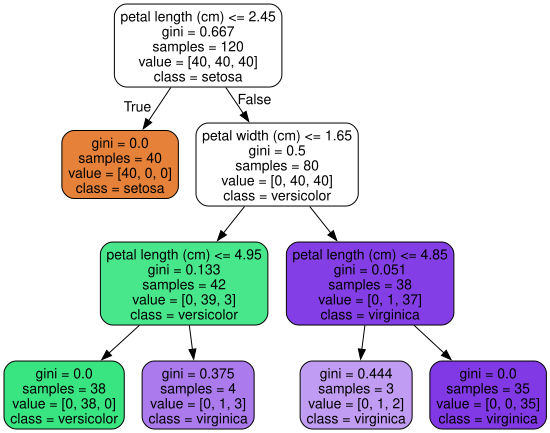

In [8]:
print("=== Gini 트리 ===")
dot_gini = export_graphviz(
    dt_gini, out_file=None,
    feature_names=feature_names, class_names=target_names,
    filled=True, rounded=True, impurity=True
)
display(graphviz.Source(dot_gini))

=== Entropy 트리 ===


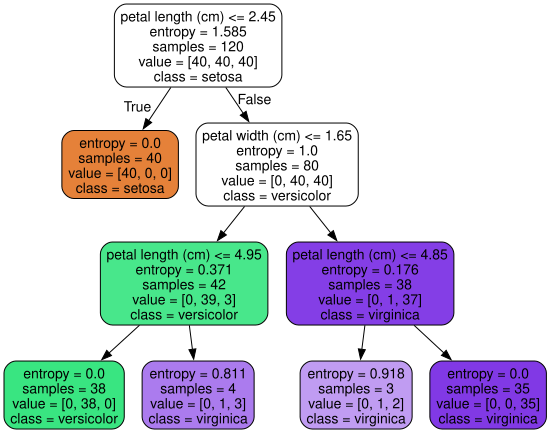

In [9]:
# Entropy 트리
print("=== Entropy 트리 ===")
dot_entropy = export_graphviz(
    dt_entropy, out_file=None,
    feature_names=feature_names, class_names=target_names,
    filled=True, rounded=True, impurity=True
)
display(graphviz.Source(dot_entropy))

> Gini와 Entropy로 만든 트리를 비교해 보면:  
> - 분기 기준(질문)이 **거의 동일**함  
> - 성능 차이도 **거의 없음**

---
## Part 5. 과적합 — max_depth=None이면 왜 위험한가?

### 과적합이란?

- 모델이 **훈련 데이터에 너무 달라붙어서** 새 데이터에서 성능이 떨어지는 현상
- 결정 트리에서는 **깊이를 제한하지 않으면** 모든 훈련 데이터를 완벽하게 외워버림

| 상황 | Train Accuracy | Test Accuracy | 상태 |
|------|:-----------:|:----------:|:----:|
| max_depth=None | **1.000** | 0.933 | 과적합 경향 |
| max_depth=3 | 0.983 | **0.967** | 적당한 균형 |

> Train=1.0인데 Test가 낮다 → 모델이 훈련 데이터를 **외운 것** (일반화 실패)

### 깊이별 성능 비교

In [10]:
depth_list = [1, 2, 3, 4, 5, 8, None]
rows = []
for depth in depth_list:
    m = DecisionTreeClassifier(max_depth=depth, random_state=42)
    m.fit(X_train, y_train)
    rows.append((
        str(depth) if depth else "None",
        accuracy_score(y_train, m.predict(X_train)),
        accuracy_score(y_test, m.predict(X_test))
    ))

depth_df = pd.DataFrame(rows, columns=["max_depth", "train_acc", "test_acc"])
display(depth_df)

,max_depth,train_acc,test_acc
0,1,0.666667,0.666667
1,2,0.966667,0.933333
2,3,0.983333,0.966667
3,4,0.991667,0.933333
4,5,1.000000,0.933333
5,8,1.000000,0.933333
6,None,1.000000,0.933333


In [11]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=depth_df["max_depth"], y=depth_df["train_acc"],
    mode="lines+markers", name="Train",
    line=dict(color="cyan", dash="dash")
))
fig.add_trace(go.Scatter(
    x=depth_df["max_depth"], y=depth_df["test_acc"],
    mode="lines+markers", name="Test",
    line=dict(color="magenta")
))
fig.update_layout(
    title="깊이(max_depth)에 따른 Train/Test Accuracy",
    xaxis_title="max_depth",
    yaxis_title="Accuracy",
    template="plotly_dark",
    yaxis=dict(range=[0.6, 1.02])
)
fig.show()

### 해석

- **max_depth=1**: 질문 1번만 → 너무 단순 (과소적합)
- **max_depth=3**: Train과 Test가 **모두 높고 가까움** 또한 **gap 차이가 적음** → 좋은 균형
- **max_depth=None**: Train=1.0이지만 Test↓ → **과적합 경향**

> 깊이가 커질수록 Train은 올라가지만, Test는 어느 순간부터 멈추거나 떨어짐  
> → 이 지점이 바로 **과적합이 시작되는 곳**!

### 과적합 vs 일반화 — Decision Boundary로 직접 보기

2D 인공 데이터(`make_classification`)로 과적합 경계와 일반화 경계를 직접 비교  

| 모델 | 경계 모양 | 특징 |
|------|----------|------|
| max_depth=None | 울퉁불퉁, 복잡 | 노이즈까지 학습 (과적합) |
| max_depth=3 | 깔끔, 단순 | 큰 패턴만 학습 (일반화) |

In [12]:
from sklearn.datasets import make_classification

X2, y2 = make_classification(
    n_samples=400,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.0,
    random_state=42
)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.3, stratify=y2, random_state=42
)

dt_free = DecisionTreeClassifier(random_state=42).fit(X2_train, y2_train)
dt_shallow = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X2_train, y2_train)

print(f"[max_depth=None] Train: {accuracy_score(y2_train, dt_free.predict(X2_train)):.3f}  "
      f"Test: {accuracy_score(y2_test, dt_free.predict(X2_test)):.3f}")
print(f"[max_depth=3   ] Train: {accuracy_score(y2_train, dt_shallow.predict(X2_train)):.3f}  "
      f"Test: {accuracy_score(y2_test, dt_shallow.predict(X2_test)):.3f}")

[max_depth=None] Train: 1.000  Test: 0.808
[max_depth=3   ] Train: 0.907  Test: 0.842


In [13]:
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
import plotly.graph_objects as go

X2, y2 = make_classification(n_samples=400, n_features=2, n_redundant=0, n_informative=2,
                             n_clusters_per_class=1, class_sep=1.0, random_state=42)

dt_free    = DecisionTreeClassifier(random_state=42).fit(X2, y2)
dt_shallow = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X2, y2)

xx, yy = np.meshgrid(np.linspace(X2[:,0].min()-1, X2[:,0].max()+1, 300),
                     np.linspace(X2[:,1].min()-1, X2[:,1].max()+1, 300))
Z1 = dt_free.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
Z2 = dt_shallow.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig = go.Figure(data=[go.Contour(x=xx[0], y=yy[:,0], z=Z1, showscale=False, opacity=0.3)])
fig.update_layout(title="Decision Boundary (max_depth=None, 과적합 경향)", template="plotly_dark")
fig.show()

fig2 = go.Figure(data=[go.Contour(x=xx[0], y=yy[:,0], z=Z2, showscale=False, opacity=0.3)])
fig2.update_layout(title="Decision Boundary (max_depth=3, 일반화 경향)", template="plotly_dark")
fig2.show()

### Decision Boundary 해석

- **max_depth=None**: 경계가 **울퉁불퉁** → 훈련 데이터의 노이즈까지 학습
  - 결정 트리는 경계가 **축에 평행한 계단 모양**으로 나타남 (if-else 규칙이니까!)
  - 깊이가 깊어질수록 계단이 촘촘해짐 → 과적합
- **max_depth=3**: 경계가 **깔끔한 큰 블록** → 큰 패턴만 학습
  - 세부 노이즈를 무시하고 전체 구조를 잡음 → 일반화 능력↑

> **핵심**: 깊이 제한 = "질문 횟수 제한" = "큰 질문만 하고 세부사항은 무시"  
> 이것이 결정 트리에서 **가장 중요한 가지치기**!

---
## Part 6. 가지치기(Pruning) — 과적합을 막는 3가지 도구

결정 트리의 과적합을 막는 주요 하이퍼파라미터:

| 파라미터 | 의미 | 효과 |
|---------|------|------|
| **`max_depth`** | 트리 최대 깊이 | 질문 횟수 제한 → 가장 강력한 가지치기 |
| **`min_samples_split`** | 분할에 필요한 **최소** 샘플 수 | 작은 노드는 더 쪼개지 않음 |
| **`min_samples_leaf`** | 잎 노드 **최소** 샘플 수 | 너무 작은 잎 노드 방지 |

### 비유

```
max_depth = "최대 몇 번 질문할 수 있나?"
min_samples_split = "최소 몇 명이 있어야 더 질문할 수 있나?"
min_samples_leaf = "마지막 그룹에 최소 몇 명은 있어야 하나?"
```

> 세 개 모두 **트리가 너무 복잡해지는 것을 방지**하는 역할!

In [14]:
dt_depth4 = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_depth4.fit(X_train, y_train)

dt_pruned = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=8,
    min_samples_leaf=4,
    random_state=42
)
dt_pruned.fit(X_train, y_train)

print(f"[depth=4 only]         Train: {accuracy_score(y_train, dt_depth4.predict(X_train)):.3f} | "
      f"Test: {accuracy_score(y_test, dt_depth4.predict(X_test)):.3f}")
print(f"[depth=4 + split/leaf] Train: {accuracy_score(y_train, dt_pruned.predict(X_train)):.3f} | "
      f"Test: {accuracy_score(y_test, dt_pruned.predict(X_test)):.3f}")

[depth=4 only]         Train: 0.992 | Test: 0.933
[depth=4 + split/leaf] Train: 0.983 | Test: 0.967


=== depth=4만 제한 ===


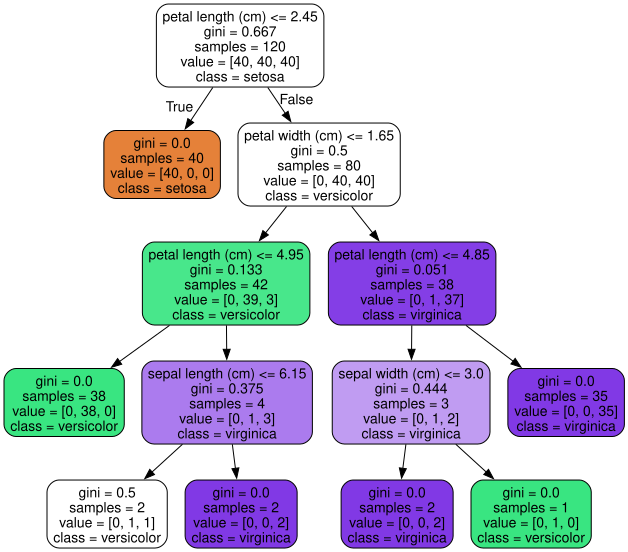

In [15]:
print("=== depth=4만 제한 ===")
dot_d4 = export_graphviz(
    dt_depth4, out_file=None,
    feature_names=feature_names, class_names=target_names,
    filled=True, rounded=True, impurity=True
)
display(graphviz.Source(dot_d4))

=== depth=4 + min_samples_split=8, min_samples_leaf=4 ===


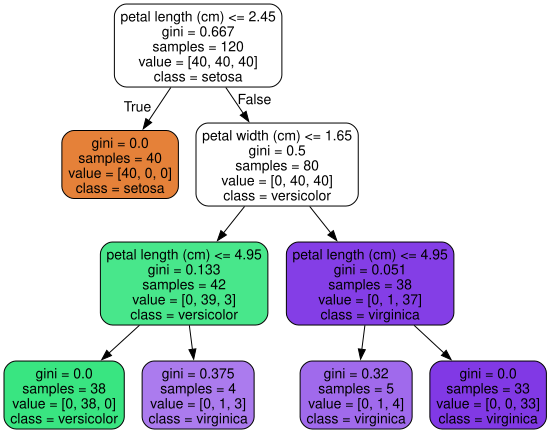

In [16]:
print("=== depth=4 + min_samples_split=8, min_samples_leaf=4 ===")
dot_pruned = export_graphviz(
    dt_pruned, out_file=None,
    feature_names=feature_names, class_names=target_names,
    filled=True, rounded=True, impurity=True
)
display(graphviz.Source(dot_pruned))

### 가지치기 결과 해석

- **depth=4만 제한**: 트리가 아직 꽤 복잡함
- **depth=4 + split/leaf 제한**: 작은 노드가 더 쪼개지지 않아 **트리가 더 단순**해짐
- Train은 약간 낮아졌지만, **Test 성능이 오히려 같거나 높아짐** → 일반화 능력 향상!

> **가지치기의 원리**:  
> "너무 세세한 질문은 하지 말고, 충분히 의미 있는 질문만 해라"  
> → 노이즈를 무시하고 핵심 패턴만 학습

---
## Part 7. Feature Importance — 어떤 변수가 중요했나?

### Feature Importance란?

결정 트리의 또 다른 장점: **어떤 피처가 분류에 가장 중요한 역할을 했는지** 알 수 있음!

- 각 분기마다 불순도를 **얼마나 줄였는지** 합산
- 값이 클수록 → 그 피처가 더 중요하게 사용됨
- 모든 importance의 합 = 1.0

| Feature Importance | 의미 |
|:------------------:|------|
| 0.6 | 이 피처가 전체 불순도 감소의 60%를 담당 |
| 0.0 | 이 피처는 분기에 한 번도 사용되지 않음 |

> **로지스틱 회귀**의 계수(coefficient)와 비슷한 역할!  
> 하지만 트리의 importance는 **비선형 관계도 반영**한다는 차이

In [17]:
# Feature Importance 시각화 (깊이 무제한 모델(예제용))
importances = pd.Series(dt.feature_importances_, index=feature_names).sort_values()

fig = px.bar(importances, orientation="h",
             title="Feature Importances (Decision Tree, max_depth=None)",
             template="plotly_dark")
fig.update_layout(xaxis_title="Importance", yaxis_title="Feature",
                  showlegend=False)
fig.show()

### Feature Importance 해석

- **petal length, petal width**가 압도적으로 중요
- 이는 Graphviz 트리에서도 확인 가능 — 루트 노드부터 petal 피처로 분기함
- sepal 피처들은 상대적으로 덜 중요

> KNN에서는 "어떤 피처가 중요한지" 알 수 없었지만,  
> 결정 트리는 **자동으로 중요한 피처를 알려줌** → 해석력의 장점!

### 주의사항

- Feature Importance는 **트리 내부의 불순도 감소 기준** 값이라, 데이터나 샘플링에 따라 달라질 수 있음
- 상관관계가 높은 피처가 여러 개 있으면, 하나만 높고 나머지는 낮게 나올 수 있음 (importance를 나눠 가지기 때문)
- Feature가 많이 사용되었단 뜻이지 인과관계가 성립하는것음 절대 아님

---
## Part 8. GridSearchCV — 최적 하이퍼파라미터 조합 탐색

### 왜 GridSearchCV인가?

가지치기 파라미터가 여러 개 있으니, **최적의 조합**을 찾아야 함  
4회차 KNN에서 배운 GridSearchCV를 동일하게 활용!

```python
param_grid = {
    "max_depth": [2, 3, 4, None],
    "min_samples_split": [2, 4, 8],
    "min_samples_leaf": [1, 2, 4]
}
# 4 × 3 × 3 = 36가지 조합을 5-Fold로 → 총 180번 학습!
```

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [2, 3, 4, None],
    "min_samples_split": [2, 4, 8],
    "min_samples_leaf": [1, 2, 4]
}

gs = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    refit=True
)
gs.fit(X_train, y_train)

print(f"최적 파라미터: {gs.best_params_}")
print(f"최적 CV Accuracy: {gs.best_score_:.4f}")

최적 파라미터: {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
최적 CV Accuracy: 0.9417


In [19]:
cv_df = pd.DataFrame(gs.cv_results_)
cv_table = cv_df[[
    "param_max_depth", "param_min_samples_split", "param_min_samples_leaf",
    "mean_test_score", "std_test_score", "rank_test_score"
]].sort_values("rank_test_score").head(5)

cv_table.columns = ["max_depth", "min_samples_split", "min_samples_leaf",
                     "cv_mean_acc", "cv_std", "rank"]
display(cv_table)

,max_depth,min_samples_split,min_samples_leaf,cv_mean_acc,cv_std,rank
18,4,2,1,0.941667,0.020412,1
27,None,2,1,0.941667,0.020412,1
20,4,8,1,0.933333,0.020412,3
21,4,2,2,0.933333,0.020412,3
22,4,4,2,0.933333,0.020412,3


### GridSearchCV 결과 해석

- `cv_mean_acc`: 5-Fold 교차검증 평균 정확도
- `cv_std`: 표준편차 (작을수록 안정적)
- `rank`: 순위 (1이 최고)

> `gs.best_estimator_`에 최적 파라미터로 **이미 학습된 모델**이 저장되어 있음  
> (`refit=True`이니까!)

---
## Part 9. 최적 모델로 최종 평가

In [20]:
best_dt = gs.best_estimator_
best_dt.fit(X_train, y_train)

y_pred_best = best_dt.predict(X_test)
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print()
print(classification_report(y_test, y_pred_best, target_names=target_names, digits=3))

Final Test Accuracy: 0.9333

              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      0.900     0.900     0.900        10
   virginica      0.900     0.900     0.900        10

    accuracy                          0.933        30
   macro avg      0.933     0.933     0.933        30
weighted avg      0.933     0.933     0.933        30



In [21]:
cm_best = confusion_matrix(y_test, y_pred_best)
fig = ff.create_annotated_heatmap(
    z=cm_best, x=list(target_names), y=list(target_names),
    colorscale="Blues", showscale=True
)
fig.update_layout(title="Confusion Matrix (Best Decision Tree)",
                  xaxis=dict(title="Predicted"), yaxis=dict(title="Actual"),
                  template="plotly_dark")
fig.show()

In [22]:
importances_best = pd.Series(best_dt.feature_importances_, index=feature_names).sort_values()

fig = px.bar(importances_best, orientation="h",
             title="Feature Importances (Best Decision Tree)",
             template="plotly_dark")
fig.update_layout(xaxis_title="Importance", yaxis_title="Feature",
                  showlegend=False)
fig.show()

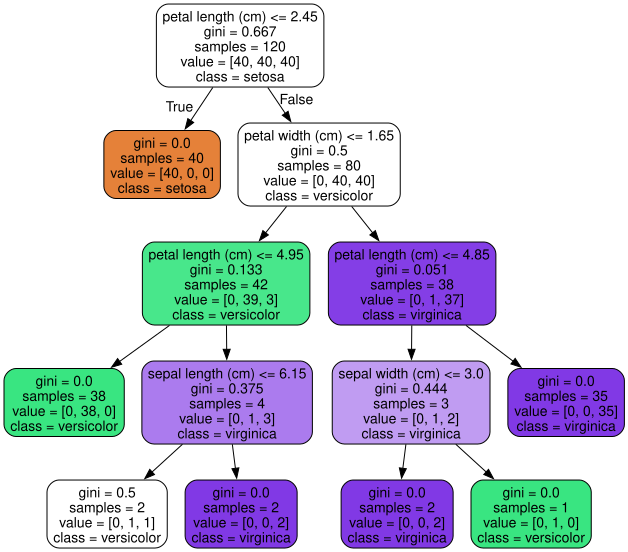

In [23]:
dot_best = export_graphviz(
    best_dt, out_file=None,
    feature_names=feature_names, class_names=target_names,
    filled=True, rounded=True, impurity=True
)
graphviz.Source(dot_best)

---
## Part 10. 실무 팁 — 결측치와 클래스 불균형 처리

결정 트리를 실무에 적용할 때 자주 만나는 두 가지 상황:

| 상황 | 문제 | 해결 |
|------|------|------|
| **결측치(NaN)** | sklearn의 DecisionTreeClassifier는 NaN 입력 불가 | `SimpleImputer`로 채우기 |
| **클래스 불균형** | 소수 클래스를 무시하고 다수 클래스만 예측 | `class_weight='balanced'` |

### 1) 결측치 처리 — SimpleImputer

실제 데이터에는 **빈 값(NaN)**이 흔함. sklearn 결정 트리는 NaN을 직접 처리하지 못하므로,  
학습 전에 `SimpleImputer`로 채워야 함.

| 전략 (strategy) | 의미 | 언제 쓰나 |
|:---:|------|------|
| `'mean'` | 평균으로 채움 | 연속형 피처 (기본값) |
| `'median'` | 중앙값으로 채움 | 이상치가 많을 때 |
| `'most_frequent'` | 최빈값으로 채움 | 범주형 피처 |

### 2) 클래스 불균형 — class_weight='balanced'

예: 정상 9,000건 vs 사기 100건 → 모델이 "전부 정상"이라 예측해도 정확도 99%  
이런 불균형 데이터에서는 `class_weight='balanced'`를 사용하면  
**소수 클래스에 더 큰 가중치**를 부여하여 균형 있는 학습이 가능

> `class_weight='balanced'`는 클래스 비율의 역수로 가중치를 자동 계산  
> 소수 클래스의 오분류 페널티가 커지므로, 소수 클래스를 더 잘 잡아냄

In [24]:
from sklearn.impute import SimpleImputer
from sklearn.datasets import make_classification

# --- 1) SimpleImputer 예시 ---
# 인공 데이터에 결측치를 일부러 넣어보자
X_demo, y_demo = make_classification(
    n_samples=200, n_features=4, n_informative=3,
    n_redundant=0, random_state=42
)
X_demo = X_demo.astype(float)

# 랜덤으로 10% 결측치 삽입
rng = np.random.RandomState(42)
mask = rng.rand(*X_demo.shape) < 0.1
X_demo[mask] = np.nan
print(f"결측치 개수: {np.isnan(X_demo).sum()}개 / 전체 {X_demo.size}개")

# SimpleImputer로 평균값 채우기
imputer = SimpleImputer(strategy='mean')
X_filled = imputer.fit_transform(X_demo)
print(f"Imputer 적용 후 결측치: {np.isnan(X_filled).sum()}개")

# 결측치 채운 데이터로 결정 트리 학습
X_tr, X_te, y_tr, y_te = train_test_split(
    X_filled, y_demo, test_size=0.3, stratify=y_demo, random_state=42
)
dt_imp = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_imp.fit(X_tr, y_tr)
print(f"\nSimpleImputer + DecisionTree Accuracy: {accuracy_score(y_te, dt_imp.predict(X_te)):.3f}")

# 2) class_weight='balanced' 예시
# 불균형 데이터 생성 (9:1 비율)
X_imb, y_imb = make_classification(
    n_samples=1000, n_features=4, n_informative=3, n_redundant=0,
    weights=[0.9, 0.1],  # 클래스 0이 90%, 클래스 1이 10%
    random_state=42
)
print(f"\n클래스 분포: 0={sum(y_imb==0)}개, 1={sum(y_imb==1)}개")

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_imb, y_imb, test_size=0.3, stratify=y_imb, random_state=42
)

# (A) 가중치 없이
dt_nw = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_nw.fit(X_tr2, y_tr2)

# (B) class_weight='balanced'
dt_bal = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
dt_bal.fit(X_tr2, y_tr2)

print("\n[가중치 없음]")
print(classification_report(y_te2, dt_nw.predict(X_te2), digits=3))
print("[class_weight='balanced']")
print(classification_report(y_te2, dt_bal.predict(X_te2), digits=3))

결측치 개수: 85개 / 전체 800개
Imputer 적용 후 결측치: 0개

SimpleImputer + DecisionTree Accuracy: 0.800

클래스 분포: 0=898개, 1=102개

[가중치 없음]
              precision    recall  f1-score   support

           0      0.974     0.993     0.983       269
           1      0.923     0.774     0.842        31

    accuracy                          0.970       300
   macro avg      0.949     0.883     0.913       300
weighted avg      0.969     0.970     0.969       300

[class_weight='balanced']
              precision    recall  f1-score   support

           0      0.996     0.870     0.929       269
           1      0.462     0.968     0.625        31

    accuracy                          0.880       300
   macro avg      0.729     0.919     0.777       300
weighted avg      0.941     0.880     0.897       300



### PR Curve (Precision-Recall Curve)로 불균형 데이터 평가

`class_weight='balanced'`를 쓰면 **recall이 올라가고 precision이 내려가는** 트레이드오프가 발생함.  
이 트레이드오프를 **한눈에** 보려면 PR Curve가 필수!

| 지표 | 의미 | 불균형 데이터에서 |
|------|------|:-----------:|
| **Accuracy** | 전체 정답 비율 | 다수 클래스에 휩쓸림 |
| **ROC-AUC** | 전체 분류력 | 낙관적으로 보일 수 있음 |
| **PR Curve / AP** | 양성 기준 분류력 | **가장 직관적!** |

> **소수 클래스(양성)를 잘 잡는 게 목표라면, PR Curve를 반드시 확인하자!**  
> AP (Average Precision) = PR 곡선 아래 면적. 높을수록 좋음.

In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# 두 모델의 확률 예측 (소수 클래스=1에 대한 확률)
y_proba_no_w = dt_nw.predict_proba(X_te2)[:, 1]
y_proba_bal  = dt_bal.predict_proba(X_te2)[:, 1]

# PR Curve 계산
prec_nw, rec_nw, thr_nw = precision_recall_curve(y_te2, y_proba_no_w)
prec_bl, rec_bl, thr_bl = precision_recall_curve(y_te2, y_proba_bal)

# AP
ap_nw = average_precision_score(y_te2, y_proba_no_w)
ap_bl = average_precision_score(y_te2, y_proba_bal)

# 양성 비율
pos_rate = y_te2.mean()

fig_pr = go.Figure()

# (A) 가중치 없음
fig_pr.add_trace(go.Scatter(
    x=rec_nw, y=prec_nw,
    mode="lines", name=f"가중치 없음 (AP={ap_nw:.3f})",
    line=dict(color="cyan", width=3)
))

# (B) class_weight='balanced'
fig_pr.add_trace(go.Scatter(
    x=rec_bl, y=prec_bl,
    mode="lines", name=f"balanced (AP={ap_bl:.3f})",
    line=dict(color="magenta", width=3)
))

fig_pr.add_trace(go.Scatter(
    x=[0, 1], y=[pos_rate, pos_rate],
    mode="lines", name=f"Baseline (pos rate={pos_rate:.2f})",
    line=dict(dash="dash", color="grey")
))

fig_pr.update_layout(
    title="PR Curve 비교: 가중치 없음 vs class_weight='balanced'",
    xaxis_title="Recall",
    yaxis_title="Precision",
    template="plotly_dark",
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1.05])
)
fig_pr.show()

print(f"[가중치 없음]          AP = {ap_nw:.3f}")
print(f"[class_weight=balanced] AP = {ap_bl:.3f}")
print(f"\n→ AP가 높을수록 소수 클래스를 정확하게 잡아내는 능력이 좋음")

[가중치 없음]          AP = 0.869
[class_weight=balanced] AP = 0.871

→ AP가 높을수록 소수 클래스를 정확하게 잡아내는 능력이 좋음


### PR Curve 해석

- **곡선이 오른쪽 위에 가까울수록** 좋은 모델 (Recall도 높고 Precision도 높음)
- **기준선(회색 점선)** = 양성 비율. 랜덤 모델이면 이 수준
- `class_weight='balanced'`는 **Recall 영역이 넓어짐** → 소수 클래스를 더 많이 잡아냄
- 대신 Precision이 일부 구간에서 내려갈 수 있음 → 이것이 트레이드오프!

> **불균형 데이터에서 Accuracy만 보면 착각할 수 있다.**  
> PR Curve를 함께 보면 "소수 클래스를 얼마나 잘 잡으면서, 얼마나 정확한지"를 한눈에 파악 가능!

---
## 로지스틱 회귀 vs KNN vs 결정 트리 — 3대 분류기 비교

| 비교 | 로지스틱 회귀 | KNN | 결정 트리 |
|------|:-----------:|:---:|:--------:|
| **분류 기준** | 확률 (Sigmoid) | 거리 (다수결) | 규칙 (if-else) |
| **경계 모양** | 직선 (선형) | 복잡한 곡선 | 축 평행 계단 |
| **해석력** | 계수로 해석 가능 | 해석 어려움 | **트리로 직접 읽기 가능** |
| **스케일링** | 권장 | **필수** | **불필요** |
| **피처 중요도** | 계수(coefficient) | 없음 | **feature_importances_** |
| **과적합 제어** | C (규제) | K (이웃 수) | max_depth, min_samples 등 |
| **고차원** | 상대적으로 강함 | 차원의 저주 | 상대적으로 강함 |
| **학습 속도** | 보통 | 학습 없음 (예측 시 계산) | 빠름 |
| **핵심 하이퍼파라미터** | C | K, metric | max_depth, min_samples |

### 결정 트리가 고차원에서 강한 이유 (KNN과의 차이)

4회차에서 KNN은 **차원의 저주**에 취약하다고 배움  
결정 트리는 왜 고차원에서도 비교적 잘 작동할까?

| KNN | 결정 트리 |
|-----|--------|
| **모든 피처를 동시에** 거리 계산 | **한 번에 하나씩** 질문 |
| 불필요한 피처도 거리에 포함 | 불필요한 피처는 **자동 무시** |
| 차원 ↑ → 모든 점이 멀어짐 | 차원 ↑ → 중요한 피처만 골라 분기 |

> 결정 트리는 **Feature Selection을 자동으로 하는 셈!**  
> 중요하지 않은 피처는 분기에 사용되지 않음 → Feature Importance = 0

---
## 오늘의 정리

| 개념 | 핵심 | 코드 |
|------|------|------|
| 결정 트리 | if-else 규칙으로 분류 (스무고개) | `DecisionTreeClassifier()` |
| 불순도 | Gini/Entropy — 섞일수록 높음 | `criterion='gini'` (기본) |
| 트리 시각화 | 사람이 규칙을 읽을 수 있음 | `export_graphviz()` + `graphviz.Source()` |
| 과적합 | depth 무제한 → Train=1.0, Test↓ | `max_depth=None` 주의 |
| 가지치기 | 트리 복잡도 제한 → 일반화↑ | `max_depth`, `min_samples_split/leaf` |
| Feature Importance | 어떤 피처가 분류에 기여했나 | `dt.feature_importances_` |
| GridSearchCV | 최적 가지치기 파라미터 탐색 | `GridSearchCV(dt, param_grid, cv=5)` |
| 결측치 처리 | NaN → 평균/중앙값으로 채움 | `SimpleImputer(strategy='mean')` |
| 클래스 불균형 | 소수 클래스 가중치 자동 부여 | `class_weight='balanced'` |

### 오늘의 핵심 문장

> **결정 트리 = 사람이 읽을 수 있는 규칙 기반 분류기**  
> 불순도를 줄이는 질문을 하나씩 던져가며 분류  
> 깊이를 제한하지 않으면 과적합 → **가지치기가 핵심!**  
> 어떤 피처가 중요한지 자동으로 알려줌 (Feature Importance)

### 기억할 흐름

```
결정 트리 학습
  → 불순도(Gini/Entropy) 기준으로 최적 분기 선택
  → 깊이 제한 없으면 과적합 위험
  → 가지치기(max_depth, min_samples)로 일반화
  → GridSearchCV로 최적 조합 탐색
  → Feature Importance로 변수 중요도 확인
  → Graphviz로 트리를 직접 읽고 해석!
```

### 실무 팁
- 결측치 있으면 `SimpleImputer` 활용 → 학습 전에 NaN 제거
- 클래스 불균형이면 `class_weight='balanced'` 옵션 자주 사용 → 소수 클래스 recall↑